# 10_training.ipynb: SSL + One-Class Training Pipeline

**Architecture**: 1D-CNN + GRU encoders (IMU + Gaze) → fusion → next-step prediction + reconstruction → Deep SVDD → proxy metrics
---

## Sections
0. Environment Setup
1. Configuration  
2. Load & Validate Data
3. Dataset Class
4. Train/Val Split
5. Model Architecture
6. SSL Training
7. Extract Embeddings
8. One-Class Detector
9. Proxy Metrics  
10. Sanity Checks
11. Manifest Update


## Section 0: Environment Setup

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import pickle
from datetime import datetime
import wandb
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

sns.set_style('whitegrid')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device selection: prioritize MPS (M1/M2/M3 Mac) > CUDA > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using device: CUDA - {torch.cuda.get_device_name(0)}')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f'Using device: MPS (Apple Silicon)')
else:
    device = torch.device('cpu')
    print(f'Using device: CPU')

try:
    import torch
    print(f'PyTorch version: {torch.__version__}')
except:
    print('PyTorch version: unknown')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')


Using device: CPU
PyTorch version: 2.6.0
NumPy version: 2.2.5
Pandas version: 2.3.1


## Section 1: Configuration

In [23]:
CONFIG = {
    'run_id': '20251117_test',
    'repo_root': Path.cwd().parent,
    'ssl': {
        'embedding_dim': 128,
        'cnn_filters': [32, 64, 128],
        'kernel_size': 3,
        'gru_hidden': 256,
        'gru_layers': 2,
        'batch_size': 32,
        'lr': 1e-3,
        'epochs': 20,
        'alpha_prediction': 1.0,
        'beta_reconstruction': 1.0,
    },
    'oneclass': {'method': 'deep_svdd', 'nu': 0.1},
}

CONFIG['run_root'] = CONFIG['repo_root'] / 'runs' / CONFIG['run_id']
CONFIG['windows_dir'] = CONFIG['run_root'] / 'windows'
CONFIG['normal_parquet'] = CONFIG['run_root'] / 'windows_normal.parquet'
CONFIG['manifest_path'] = CONFIG['run_root'] / 'manifest.json'

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
CONFIG['ssl_output_dir'] = CONFIG['run_root'] / 'models' / 'ssl' / timestamp
CONFIG['reports_dir'] = CONFIG['run_root'] / 'reports' / 'training' / timestamp

for p in [CONFIG['ssl_output_dir'], CONFIG['reports_dir']]:
    p.mkdir(parents=True, exist_ok=True)

print(f"RUN_ID: {CONFIG['run_id']}")
print(f"Run root: {CONFIG['run_root']}")

# Initialize WandB
wandb_api_key = os.getenv('WANDB_API_KEY')
if not wandb_api_key:
    raise ValueError("WANDB_API_KEY not found in environment. Please create a .env file with your key.")
wandb.login(key=wandb_api_key)

wandb.init(
    project='AR_Glasses_Anomaly_Detection',
    name=f"{CONFIG['run_id']}_{timestamp}",
    config={
        'run_id': CONFIG['run_id'],
        'embedding_dim': CONFIG['ssl']['embedding_dim'],
        'cnn_filters': CONFIG['ssl']['cnn_filters'],
        'kernel_size': CONFIG['ssl']['kernel_size'],
        'gru_hidden': CONFIG['ssl']['gru_hidden'],
        'gru_layers': CONFIG['ssl']['gru_layers'],
        'batch_size': CONFIG['ssl']['batch_size'],
        'lr': CONFIG['ssl']['lr'],
        'epochs': CONFIG['ssl']['epochs'],
        'alpha_prediction': CONFIG['ssl']['alpha_prediction'],
        'beta_reconstruction': CONFIG['ssl']['beta_reconstruction'],
        'oneclass_method': CONFIG['oneclass']['method'],
        'oneclass_nu': CONFIG['oneclass']['nu'],
        'seed': SEED,
        'device': str(device),
    },
    tags=[CONFIG['run_id'], 'ssl', 'deep-svdd'],
    notes=f"SSL training for {CONFIG['run_id']}",
)

# Define epoch-level metrics (so they show up properly in wandb UI)
wandb.define_metric("epoch", step_metric="epoch")
wandb.define_metric("train/loss", step_metric="epoch")
wandb.define_metric("val/loss", step_metric="epoch")
wandb.define_metric("train/learning_rate", step_metric="epoch")
wandb.define_metric("best_val_loss", step_metric="epoch")

# Define batch-level metrics (optional, for detailed monitoring)
wandb.define_metric("batch/train_loss", step_metric="batch_step")
wandb.define_metric("batch/reconstruction_loss", step_metric="batch_step")

print(f"✅ WandB initialized: {wandb.run.url}")


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


RUN_ID: 20251117_test
Run root: /Users/leodas/Documents/ETHZ/Boston/Thesis/AI_and_Robotics_Harvard/AR_project/HAR_Lab_Initiative_AI/runs/20251117_test


batch/reconstruction_loss,▃▄▄▂▂▂▁▂▂▃▂▃▂▁▆▂▆▂▁▁▁▂▁█▂▁▁▁▁▂▁▂▁▁▂▁▁▂▂▁
batch/train_loss,▃▃▂▄▄▂▁▃▃▂▁▆▂▆▂▂▁▁▁█▂▁▁▁▁▁▂▁▂▁▁▂▁▁▁▃▂▂▁▁
batch/reconstruction_loss,0.36267
batch/train_loss,0.36267


✅ WandB initialized: https://wandb.ai/wandbleo/egoexo-ssl-training/runs/0y7q5onc


## Section 2: Load & Validate Data

In [24]:
assert CONFIG['normal_parquet'].exists(), f"Missing: {CONFIG['normal_parquet']}"
assert CONFIG['manifest_path'].exists(), f"Missing: {CONFIG['manifest_path']}"

manifest = json.loads(CONFIG['manifest_path'].read_text())
normal_df = pd.read_parquet(CONFIG['normal_parquet'])

print(f"Total normal windows: {len(normal_df)}")
print(f"Unique takes: {normal_df['take_uid'].nunique()}")


Total normal windows: 21853
Unique takes: 40


## Section 3: Dataset Class

In [25]:
class EgoExoDataset(torch.utils.data.Dataset):
    def __init__(self, take_uids, windows_dir):
        self.samples = []
        for uid in tqdm(take_uids, desc='Loading'):
            seq_path = Path(windows_dir) / uid / 'seq.npz'
            if not seq_path.exists():
                continue
            data = np.load(seq_path)
            for i in range(len(data['gaze'])):
                self.samples.append({
                    'take_uid': uid,
                    'window_idx': i,
                    'gaze': torch.FloatTensor(data['gaze'][i]),
                    'traj': torch.FloatTensor(data['traj'][i]),
                })
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        return self.samples[idx]

# Test
test_uids = list(normal_df['take_uid'].unique())[:2]
test_ds = EgoExoDataset(test_uids, CONFIG['windows_dir'])
print(f"Test dataset: {len(test_ds)} samples")
if len(test_ds) > 0:
    print(f"Sample shapes - gaze: {test_ds[0]['gaze'].shape}, traj: {test_ds[0]['traj'].shape}")


Loading: 100%|██████████| 2/2 [01:19<00:00, 39.62s/it]

Test dataset: 4819 samples
Sample shapes - gaze: torch.Size([50, 4]), traj: torch.Size([50, 3])


## Section 4: Train/Val/Test Split

In [26]:
take_uids = normal_df['take_uid'].unique()
np.random.shuffle(take_uids)

n = len(take_uids)
train_uids = take_uids[:int(0.7*n)]
val_uids = take_uids[int(0.7*n):int(0.85*n)]
test_uids = take_uids[int(0.85*n):]

print(f"Train: {len(train_uids)}, Val: {len(val_uids)}, Test: {len(test_uids)}")

train_dataset = EgoExoDataset(train_uids, CONFIG['windows_dir'])
val_dataset = EgoExoDataset(val_uids, CONFIG['windows_dir'])
test_dataset = EgoExoDataset(test_uids, CONFIG['windows_dir'])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=CONFIG['ssl']['batch_size'], shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=CONFIG['ssl']['batch_size'], shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=CONFIG['ssl']['batch_size'], shuffle=False)

print(f"Train windows: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 28, Val: 6, Test: 6


Loading: 100%|██████████| 6/6 [04:48<00:00, 48.06s/it]


Train windows: 75687, Val: 18587, Test: 13969


## Section 5: Model Architecture

In [27]:
class Encoder(nn.Module):
    def __init__(self, in_ch, config):
        super().__init__()
        filters = config['ssl']['cnn_filters']
        self.convs = nn.ModuleList([
            nn.Conv1d(in_ch if i==0 else filters[i-1], filters[i], 3, padding='same')
            for i in range(len(filters))
        ])
        self.bns = nn.ModuleList([nn.BatchNorm1d(f) for f in filters])
        self.gru = nn.GRU(filters[-1], config['ssl']['gru_hidden'], config['ssl']['gru_layers'], batch_first=True)
        self.fc = nn.Linear(config['ssl']['gru_hidden'], config['ssl']['embedding_dim'])
    
    def forward(self, x):
        x = x.transpose(1, 2)
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x)))
        x = x.transpose(1, 2)
        _, h = self.gru(x)
        return self.fc(h[-1])

class SSLModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.imu_enc = Encoder(3, config)  # traj has 3 channels
        self.gaze_enc = Encoder(4, config)  # gaze has 4 channels
        self.fusion = nn.Sequential(
            nn.LayerNorm(config['ssl']['embedding_dim']*2),
            nn.Linear(config['ssl']['embedding_dim']*2, config['ssl']['embedding_dim']),
            nn.ReLU()
        )
        # TODO: Predictor head not currently used (returns hardcoded 0.0 loss)
        # Uncomment to implement next-step prediction loss (see REFLECTION.md)
        # self.predictor = nn.Linear(config['ssl']['embedding_dim'], config['ssl']['embedding_dim'])
        self.imu_dec = nn.Linear(config['ssl']['embedding_dim'], 3)
        self.gaze_dec = nn.Linear(config['ssl']['embedding_dim'], 4)
    
    def encode(self, batch):
        imu_emb = self.imu_enc(batch['traj'])
        gaze_emb = self.gaze_enc(batch['gaze'])
        return self.fusion(torch.cat([imu_emb, gaze_emb], 1))
    
    def forward(self, batch):
        emb = self.encode(batch)
        imu_recon = self.imu_dec(emb)
        gaze_recon = self.gaze_dec(emb)
        loss_recon = F.mse_loss(imu_recon, batch['traj'].mean(1)) + F.mse_loss(gaze_recon, batch['gaze'].mean(1))
        # Return only reconstruction loss (predictor not implemented)
        return emb, torch.tensor(0.0, device=emb.device), loss_recon

model = SSLModel(CONFIG).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Parameters: 1,545,959


## Section 6: SSL Training

In [28]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['ssl']['lr'])
history = {'train_loss': [], 'val_loss': []}
best_val_loss = 1

# Log model architecture to wandb
wandb.watch(model, log='all', log_freq=100)

for epoch in range(CONFIG['ssl']['epochs']):
    model.train()
    train_loss = 0
    num_batches = 0
    
    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        _, loss_p, loss_r = model(batch)
        loss = CONFIG['ssl']['beta_reconstruction'] * loss_r
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        num_batches += 1
        
        # Log batch-level metrics (every 100 batches to reduce noise)
        if num_batches % 100 == 0:
            wandb.log({
                'batch/train_loss': loss.item(),
                'batch/reconstruction_loss': loss_r.item(),
                'batch_step': epoch * len(train_loader) + num_batches,
            })
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
            _, _, loss_r = model(batch)
            val_loss += loss_r.item()
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    # Log epoch-level metrics to wandb
    log_dict = {
        'epoch': epoch + 1,  # This is the step_metric for epoch-level metrics
        'train/loss': avg_train_loss,
        'val/loss': avg_val_loss,
        'train/learning_rate': optimizer.param_groups[0]['lr'],
    }
    
    print(f"Epoch {epoch+1}: Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}")
    
    # ✅ if val loss is lower, save it
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        log_dict['best_val_loss'] = best_val_loss
        
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'val_loss': best_val_loss,
        }, CONFIG['ssl_output_dir'] / 'best_model.pt')
        
        # Log best model artifact to wandb
        artifact = wandb.Artifact('best_model', type='model')
        artifact.add_file(str(CONFIG['ssl_output_dir'] / 'best_model.pt'))
        wandb.log_artifact(artifact)
        
        print(f"  ✓ New best model saved(val_loss={best_val_loss:.4f})")

    # constant save latest checkpoint（every 5 epochs）
    elif (epoch + 1) % 5 == 0:
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
        }, CONFIG['ssl_output_dir'] / 'latest_checkpoint.pt')
        
        log_dict['checkpoint_saved'] = True
    
    # Log epoch metrics with epoch as the step metric
    wandb.log(log_dict)

# Save final model
torch.save(model.state_dict(), CONFIG['ssl_output_dir'] / 'model.pt')
pd.DataFrame(history).to_csv(CONFIG['reports_dir'] / 'history.csv', index=False)

# Log final summary
wandb.summary['final_train_loss'] = history['train_loss'][-1]
wandb.summary['final_val_loss'] = history['val_loss'][-1]
wandb.summary['best_val_loss'] = best_val_loss
wandb.summary['best_epoch'] = np.argmin(history['val_loss']) + 1

print("✅ Training complete. Metrics logged to WandB.")


Epoch 1: 100%|██████████| 2366/2366 [2:41:59<00:00,  4.11s/it]  


Epoch 1: Train=1.7102, Val=0.4814
  ✓ New best model saved(val_loss=0.4814)


Epoch 2: 100%|██████████| 2366/2366 [55:58<00:00,  1.42s/it] 


Epoch 2: Train=0.7852, Val=0.1849
  ✓ New best model saved(val_loss=0.1849)


Epoch 3: 100%|██████████| 2366/2366 [58:00<00:00,  1.47s/it]  


...

Epoch 18: 100%|██████████| 2366/2366 [1:21:01<00:00,  2.05s/it]


Epoch 18: Train=0.1381, Val=0.0886


Epoch 19: 100%|██████████| 2366/2366 [8:57:41<00:00, 13.64s/it]      


Epoch 19: Train=0.1336, Val=0.0631


AuthenticationError: Unable to connect to server to verify API token.


=== Training Summary ===
Total epochs: 19
Final train loss: 0.1336
Final val loss: 0.0631
Best val loss: 0.0631 (epoch 19)


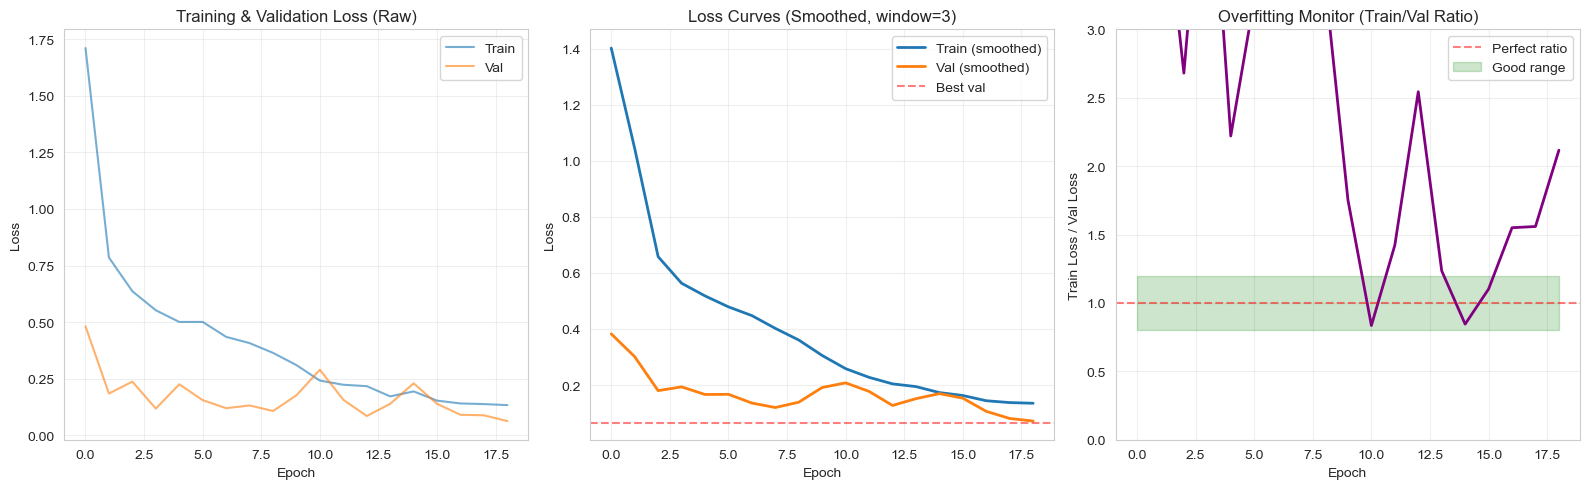

✅ Saved enhanced training curves


In [30]:
# === Enhanced Training Visualization ===

print("\n=== Training Summary ===")
print(f"Total epochs: {len(history['train_loss'])}")
print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss: {history['val_loss'][-1]:.4f}")
print(f"Best val loss: {min(history['val_loss']):.4f} (epoch {np.argmin(history['val_loss'])+1})")

# Visualization 1: Loss curves (smoothed)
from scipy.ndimage import uniform_filter1d

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: Raw loss
axes[0].plot(history['train_loss'], label='Train', alpha=0.6)
axes[0].plot(history['val_loss'], label='Val', alpha=0.6)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss (Raw)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Middle: Smoothed loss
window_size = max(3, len(history['train_loss']) // 10)
train_smooth = uniform_filter1d(history['train_loss'], size=window_size)
val_smooth = uniform_filter1d(history['val_loss'], size=window_size)

axes[1].plot(train_smooth, label='Train (smoothed)', linewidth=2)
axes[1].plot(val_smooth, label='Val (smoothed)', linewidth=2)
axes[1].axhline(min(history['val_loss']), color='r', linestyle='--', alpha=0.5, label='Best val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title(f'Loss Curves (Smoothed, window={window_size})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Right: Train/Val ratio
loss_ratio = np.array(history['train_loss']) / (np.array(history['val_loss']) + 1e-8)
axes[2].plot(loss_ratio, color='purple', linewidth=2)
axes[2].axhline(1.0, color='r', linestyle='--', alpha=0.5, label='Perfect ratio')
axes[2].fill_between(range(len(loss_ratio)), 0.8, 1.2, alpha=0.2, color='green', label='Good range')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Train Loss / Val Loss')
axes[2].set_title('Overfitting Monitor (Train/Val Ratio)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 3])

plt.tight_layout()
plt.savefig(CONFIG['reports_dir'] / 'training_curves_enhanced.png', dpi=150, bbox_inches='tight')

# Log plot to wandb
wandb.log({'training_curves': wandb.Image(fig)})

plt.show()
plt.close(fig)  # Close to free memory

print(f"✅ Saved enhanced training curves")

## Section 7: Extract Embeddings

In [31]:
def extract_emb(loader):
    model.eval()
    embs, metas = [], []
    with torch.no_grad():
        for batch in tqdm(loader):
            batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
            emb = model.encode(batch)
            embs.append(emb.cpu().numpy())
            metas.extend([{'take_uid': batch['take_uid'][i], 'window_idx': batch['window_idx'][i].item()} 
                         for i in range(len(batch['take_uid']))])
    return np.vstack(embs), metas

train_emb, _ = extract_emb(train_loader)
val_emb, _ = extract_emb(val_loader)
test_emb, _ = extract_emb(test_loader)
print(f"Embeddings: Train={train_emb.shape}, Val={val_emb.shape}, Test={test_emb.shape}")


100%|██████████| 437/437 [11:33<00:00,  1.59s/it]

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


Embeddings: Train=(75687, 128), Val=(18587, 128), Test=(13969, 128)


## Section 8: One-Class Detector (Deep SVDD)

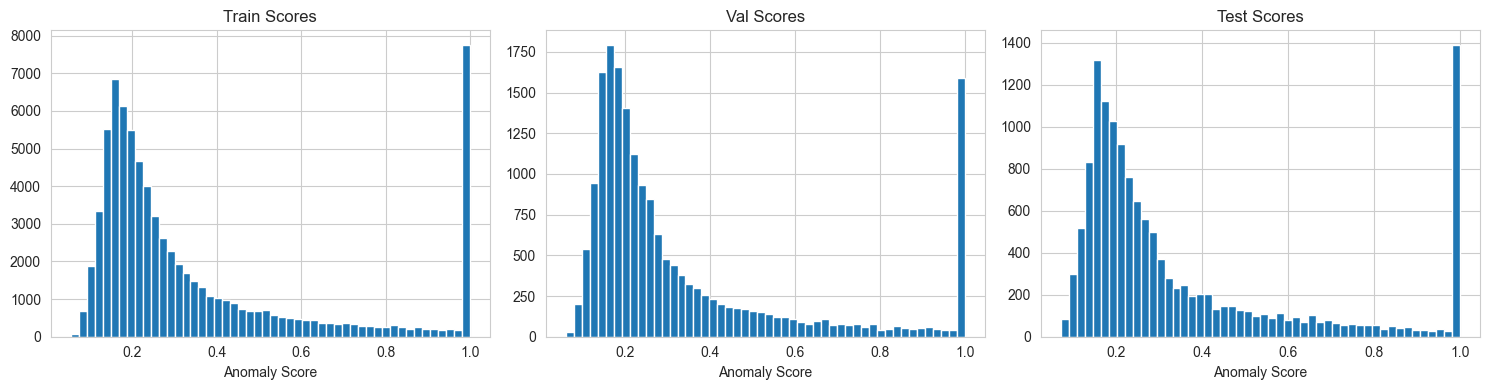

In [ ]:
class DeepSVDD:
    def __init__(self, nu=0.1):
        self.nu = nu
        self.center = None
        self.R = None
    
    def fit(self, embs):
        self.center = torch.FloatTensor(embs.mean(0))
        dists = torch.sum((torch.FloatTensor(embs) - self.center)**2, 1)
        self.R = torch.quantile(dists, 1-self.nu).item()
    
    def score(self, embs):
        dists = torch.sum((torch.FloatTensor(embs) - self.center)**2, 1).numpy()
        return np.clip(dists / self.R, 0, 1)

svdd = DeepSVDD(CONFIG['oneclass']['nu'])
svdd.fit(train_emb)

train_scores = svdd.score(train_emb)
val_scores = svdd.score(val_emb)
test_scores = svdd.score(test_emb)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, scores, name in zip(axes, [train_scores, val_scores, test_scores], ['Train', 'Val', 'Test']):
    ax.hist(scores, bins=50)
    ax.set_title(f'{name} Scores')
    ax.set_xlabel('Anomaly Score')
plt.tight_layout()
plt.savefig(CONFIG['reports_dir'] / 'scores.png', dpi=150)
plt.show()

# Save scores for easy access
scores_df = pd.DataFrame({
    'take_uid': [test_dataset[i]['take_uid'] for i in range(len(test_scores))],
    'window_idx': [test_dataset[i]['window_idx'].item() for i in range(len(test_scores))],
    'anomaly_score': test_scores,
    'distance': np.linalg.norm(test_emb - svdd.center.cpu().numpy(), axis=1),
})
scores_df.to_csv(CONFIG['reports_dir'] / 'test_scores.csv', index=False)
print(f"✅ Saved test scores to: {CONFIG['reports_dir'] / 'test_scores.csv'}")


### 8.1 Test Single Sample Helper


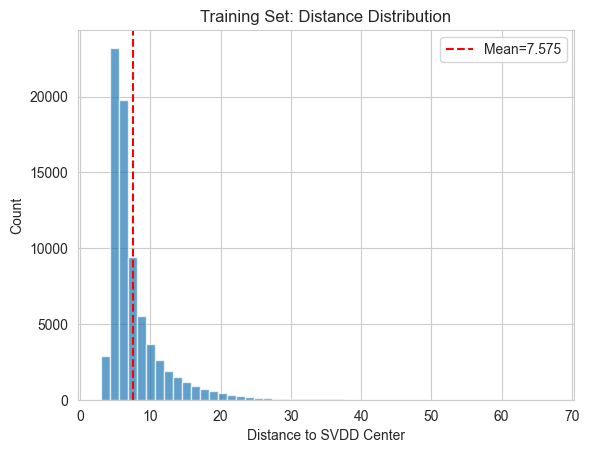

Train distance: mean=7.5751, std=4.2522
Train distance: min=2.9033, max=67.1125


In [18]:
center_np = svdd.center.cpu().numpy()
train_dists = np.linalg.norm(train_emb - center_np, axis=1)

plt.hist(train_dists, bins=50, alpha=0.7)
plt.axvline(train_dists.mean(), color='r', linestyle='--',
label=f'Mean={train_dists.mean():.3f}')
plt.xlabel('Distance to SVDD Center')
plt.ylabel('Count')
plt.legend()
plt.title('Training Set: Distance Distribution')
plt.show()

print(f"Train distance: mean={train_dists.mean():.4f}, std={train_dists.std():.4f}")
print(f"Train distance: min={train_dists.min():.4f}, max={train_dists.max():.4f}")

In [ ]:
test_scores_with_idx = list(zip(test_scores,range(len(test_scores))))
top_anomalies = sorted(test_scores_with_idx,reverse=True)[:10]

print("Top 10 anomalous windows in test set:")
for score, idx in top_anomalies:
    
    test_dataset_item = test_dataset[idx]
    take_uid = test_dataset_item['take_uid']
    window_idx = test_dataset_item['window_idx']

    print(f"  Score={score:.4f} | Take={take_uid} | Window={window_idx}")


    seq_path = CONFIG['windows_dir'] / take_uid / 'seq.npz'
    seq = np.load(seq_path)
    gaze = seq['gaze'][window_idx]  # (50, 4)
    traj = seq['traj'][window_idx]  # (50, 3)

  
    gaze_std = gaze.std(axis=0).mean()
    traj_std = traj.std(axis=0).mean()

    print(f"Gaze std={gaze_std:.4f}, Traj std={traj_std:.4f}")

Top 10 anomalous windows in test set:
  Score=1.0000 | Take=c726ae4b-d68f-4b59-9c41-47a4615eef51 | Window=4257
Gaze std=3.7438, Traj std=7.7408
  Score=1.0000 | Take=c726ae4b-d68f-4b59-9c41-47a4615eef51 | Window=4256
Gaze std=3.6545, Traj std=6.9663
  Score=1.0000 | Take=c726ae4b-d68f-4b59-9c41-47a4615eef51 | Window=4255
Gaze std=3.7400, Traj std=7.3873
  Score=1.0000 | Take=c726ae4b-d68f-4b59-9c41-47a4615eef51 | Window=4254
Gaze std=4.2011, Traj std=8.1038
  Score=1.0000 | Take=c726ae4b-d68f-4b59-9c41-47a4615eef51 | Window=4253
Gaze std=4.2246, Traj std=7.1474
  Score=1.0000 | Take=c726ae4b-d68f-4b59-9c41-47a4615eef51 | Window=4252
Gaze std=4.4238, Traj std=7.3595
  Score=1.0000 | Take=c726ae4b-d68f-4b59-9c41-47a4615eef51 | Window=4251
Gaze std=4.6491, Traj std=7.8645
  Score=1.0000 | Take=c726ae4b-d68f-4b59-9c41-47a4615eef51 | Window=4250
Gaze std=4.6778, Traj std=7.4677
  Score=1.0000 | Take=c726ae4b-d68f-4b59-9c41-47a4615eef51 | Window=4249
Gaze std=4.7380, Traj std=7.1393
  Score=

In [20]:
all_stats = []
for take_dir in CONFIG['windows_dir'].iterdir():
    if take_dir.is_dir():
        stats_path = take_dir / 'stats.parquet'
        if stats_path.exists():
            all_stats.append(pd.read_parquet(stats_path))

all_stats_df = pd.concat(all_stats, ignore_index=True)
normal_df = pd.read_parquet(CONFIG['normal_parquet'])

print(f"Total windows: {len(all_stats_df)}")
print(f"Normal windows: {len(normal_df)}")
print(f"Normal ratio: {len(normal_df) / len(all_stats_df) * 100:.1f}%")

Total windows: 108243
Normal windows: 21853
Normal ratio: 20.2%


In [ ]:
normal_df = pd.read_parquet(CONFIG['normal_parquet'])

print("Normal windows statistics:")
print(f"  Gaze std: mean={normal_df['gaze_std'].mean():.2f},"
    f"P50={normal_df['gaze_std'].median():.2f}, "
    f"P90={normal_df['gaze_std'].quantile(0.9):.2f}, "
    f"max={normal_df['gaze_std'].max():.2f}")

print(f"  Traj std: mean={normal_df['traj_std'].mean():.2f},"
    f"P50={normal_df['traj_std'].median():.2f}, "
    f"P90={normal_df['traj_std'].quantile(0.9):.2f}, "
    f"max={normal_df['traj_std'].max():.2f}")

# Compare anomalous windows
print("\nTop anomaly window:")
print(f"  Gaze std: 4.3-5.2")
print(f"  Traj std: 7.8-14.9")


In [ ]:
take_uid = '094d3625-cd1e-45b1-8e08-4ee8727d0159'
seq_path = CONFIG['windows_dir'] / take_uid / 'seq.npz'
seq = np.load(seq_path)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Anomaly Segment: Windows 370-375 (Take {take_uid[:8]}...)')

for i, win_idx in enumerate(range(370, 376)):
    row = i // 3
    col = i % 3

    gaze = seq['gaze'][win_idx]  # (50, 4)
    traj = seq['traj'][win_idx]  # (50, 3)

    ax = axes[row, col]
    ax.plot(traj[:, 0], label='Traj X', alpha=0.7)
    ax.plot(traj[:, 1], label='Traj Y', alpha=0.7)
    ax.plot(traj[:, 2], label='Traj Z', alpha=0.7)
    ax.set_title(f'Win {win_idx}')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()

normal_idx = np.argmin(test_scores)
normal_item = test_dataset[normal_idx]
normal_take = normal_item['take_uid']
normal_win = normal_item['window_idx']

print(f"\nLow-score (normal) window for comparison:")
print(f"  Score={test_scores[normal_idx]:.4f} | Take={normal_take} | Window={normal_win}")

seq_path_normal = CONFIG['windows_dir'] / normal_take / 'seq.npz'
seq_normal = np.load(seq_path_normal)
gaze_normal = seq_normal['gaze'][normal_win]
traj_normal = seq_normal['traj'][normal_win]

print(f"  Gaze std={gaze_normal.std(axis=0).mean():.4f}")
print(f"  Traj std={traj_normal.std(axis=0).mean():.4f}")

print(f"  Gaze abnor std={gaze.std(axis=0).mean():.4f}")
print(f"  Traj abnor std={traj.std(axis=0).mean():.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(traj_normal[:, 0], label='Traj X', alpha=0.7)
plt.plot(traj_normal[:, 1], label='Traj Y', alpha=0.7)
plt.plot(traj_normal[:, 2], label='Traj Z', alpha=0.7)
plt.title(f'Normal Window (Score={test_scores[normal_idx]:.2f})')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(traj[:, 0], label='Traj X', alpha=0.7)
plt.plot(traj[:, 1], label='Traj Y', alpha=0.7)
plt.plot(traj[:, 2], label='Traj Z', alpha=0.7)
plt.title(f'Anomalous Window (Score=1.0)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/windows/094d3625-cd1e-45b1-8e08-4ee8727d0159/seq.npz'

## Section 9: Proxy Metrics

=== Computing Detection Metrics ===

=== Distance Statistics ===
Train: mean=7.58, std=4.25, min=2.90, max=67.11
Val:   mean=7.20, std=3.41, min=3.04, max=26.50
Test:  mean=7.38, std=3.42, min=3.32, max=26.08

=== Tiered Thresholds (from training set) ===
  LOW  (P85): 10.53
  MID  (P95): 16.06
  HIGH (P99): 23.73

=== Detection Rates (Test Set) ===
  LOW  alerts:  176.7/hour  (2057 windows)
  MID  alerts:   44.7/hour  ( 520 windows)
  HIGH alerts:    1.1/hour  (  13 windows)

=== Target Compliance ===
  Target: HIGH ≤ 2.0/hour
  Actual: 1.1/hour
  Status: ✅ PASS

=== Duty Cycles ===
  LOW:  14.7%
  MID:  3.7%
  HIGH: 0.1%


/var/folders/4z/hvk3zszd0ys3029345c617yc0000gn/T/ipykernel_31626/3100944368.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(data_to_plot, labels=['Train', 'Val', 'Test'], patch_artist=True)


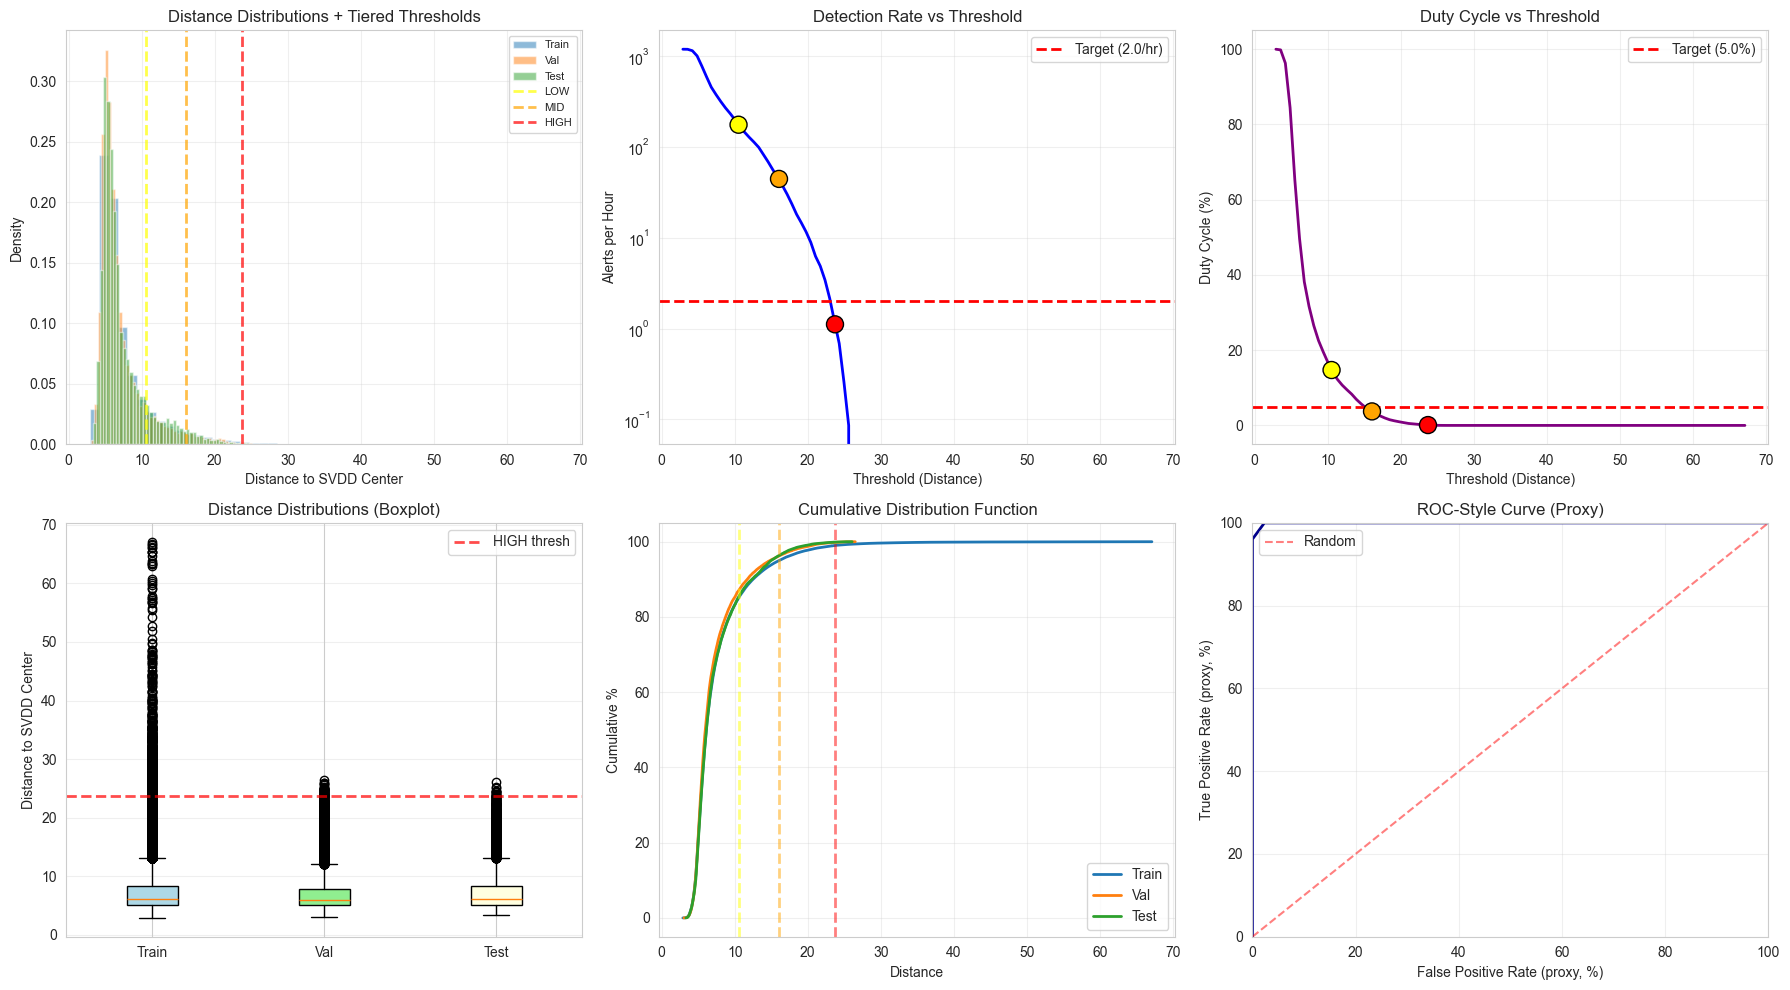


✅ Saved comprehensive metrics visualization
✅ Saved metrics summary to /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/reports/training/20251112_131835/tiered_metrics.json


In [ ]:
### Section 9: Proxy Metrics (Tiered + Enhanced)


# === Section 9: Tiered Proxy Metrics (Enhanced) ===

import numpy as np
import matplotlib.pyplot as plt

print("=== Computing Detection Metrics ===")

# Compute distances
center_np = svdd.center.cpu().numpy()
train_dists = np.linalg.norm(train_emb - center_np, axis=1)
val_dists = np.linalg.norm(val_emb - center_np, axis=1)
test_dists = np.linalg.norm(test_emb - center_np, axis=1)

# Distance statistics
print(f"\n=== Distance Statistics ===")
print(f"Train: mean={train_dists.mean():.2f}, std={train_dists.std():.2f}, min={train_dists.min():.2f}, max={train_dists.max():.2f}")
print(f"Val:   mean={val_dists.mean():.2f}, std={val_dists.std():.2f}, min={val_dists.min():.2f}, max={val_dists.max():.2f}")
print(f"Test:  mean={test_dists.mean():.2f}, std={test_dists.std():.2f}, min={test_dists.min():.2f}, max={test_dists.max():.2f}")

# Define tiered thresholds
LOW_THRESH = np.percentile(train_dists, 85)   # Detect top 15%
MID_THRESH = np.percentile(train_dists, 95)   # Detect top 5%
HIGH_THRESH = np.percentile(train_dists, 99)  # Detect top 1%

print(f"\n=== Tiered Thresholds (from training set) ===")
print(f"  LOW  (P85): {LOW_THRESH:.2f}")
print(f"  MID  (P95): {MID_THRESH:.2f}")
print(f"  HIGH (P99): {HIGH_THRESH:.2f}")

# Compute detection rates
window_size = manifest.get('parameters',{}).get('window_sec', 3.0)
test_hours = len(test_dataset) * window_size / 3600

low_rate = (test_dists > LOW_THRESH).sum() / test_hours
mid_rate = (test_dists > MID_THRESH).sum() / test_hours
high_rate = (test_dists > HIGH_THRESH).sum() / test_hours

print(f"\n=== Detection Rates (Test Set) ===")
print(f"  LOW  alerts: {low_rate:6.1f}/hour  ({(test_dists > LOW_THRESH).sum():4d} windows)")
print(f"  MID  alerts: {mid_rate:6.1f}/hour  ({(test_dists > MID_THRESH).sum():4d} windows)")
print(f"  HIGH alerts: {high_rate:6.1f}/hour  ({(test_dists > HIGH_THRESH).sum():4d} windows)")

# Target compliance

target_high = manifest.get('metrics',{}).get('target_fp_hour', 2.0)
status = "✅ PASS" if high_rate <= target_high else f"⚠️  OVER"
print(f"\n=== Target Compliance ===")
print(f"  Target: HIGH ≤ {target_high}/hour")
print(f"  Actual: {high_rate:.1f}/hour")
print(f"  Status: {status}")
if high_rate > target_high:
    print(f"  Gap: +{high_rate - target_high:.1f}/hour ({(high_rate/target_high - 1)*100:.0f}% over)")

# Duty cycles
duty_low = (test_dists > LOW_THRESH).sum() / len(test_dists) * 100
duty_mid = (test_dists > MID_THRESH).sum() / len(test_dists) * 100
duty_high = (test_dists > HIGH_THRESH).sum() / len(test_dists) * 100

print(f"\n=== Duty Cycles ===")
print(f"  LOW:  {duty_low:.1f}%")
print(f"  MID:  {duty_mid:.1f}%")
print(f"  HIGH: {duty_high:.1f}%")

# === Enhanced Visualization ===

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1, Col 1: Distance distributions with thresholds
axes[0, 0].hist(train_dists, bins=50, alpha=0.5, label='Train', density=True)
axes[0, 0].hist(val_dists, bins=50, alpha=0.5, label='Val', density=True)
axes[0, 0].hist(test_dists, bins=50, alpha=0.5, label='Test', density=True)
axes[0, 0].axvline(LOW_THRESH, color='yellow', linestyle='--', alpha=0.7, linewidth=2, label='LOW')
axes[0, 0].axvline(MID_THRESH, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='MID')
axes[0, 0].axvline(HIGH_THRESH, color='red', linestyle='--', alpha=0.7, linewidth=2, label='HIGH')
axes[0, 0].set_xlabel('Distance to SVDD Center')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Distance Distributions + Tiered Thresholds')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Row 1, Col 2: Detection rate vs threshold
thresholds_sweep = np.linspace(train_dists.min(), train_dists.max(), 100)
rates_sweep = [(test_dists > t).sum() / test_hours for t in thresholds_sweep]

axes[0, 1].plot(thresholds_sweep, rates_sweep, linewidth=2, color='blue')
axes[0, 1].axhline(target_high, color='r', linestyle='--', linewidth=2, label=f'Target ({target_high}/hr)')
axes[0, 1].scatter([LOW_THRESH, MID_THRESH, HIGH_THRESH],
                   [low_rate, mid_rate, high_rate],
                   color=['yellow', 'orange', 'red'], s=150, zorder=5, edgecolors='black')
axes[0, 1].set_xlabel('Threshold (Distance)')
axes[0, 1].set_ylabel('Alerts per Hour')
axes[0, 1].set_title('Detection Rate vs Threshold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_yscale('log')

# Row 1, Col 3: Duty cycle vs threshold
duties_sweep = [(test_dists > t).sum() / len(test_dists) * 100 for t in thresholds_sweep]

axes[0, 2].plot(thresholds_sweep, duties_sweep, linewidth=2, color='purple')
metrics_cfg = manifest.get('metrics', {})
target_duty_pct = metrics_cfg.get('target_duty_cycle', 5.0)
axes[0, 2].axhline(target_duty_pct, color='r', linestyle='--',
                   linewidth=2, label=f'Target ({target_duty_pct}%)')
axes[0, 2].scatter([LOW_THRESH, MID_THRESH, HIGH_THRESH],
                   [duty_low, duty_mid, duty_high],
                   color=['yellow', 'orange', 'red'], s=150, zorder=5, edgecolors='black')
axes[0, 2].set_xlabel('Threshold (Distance)')
axes[0, 2].set_ylabel('Duty Cycle (%)')
axes[0, 2].set_title('Duty Cycle vs Threshold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Row 2, Col 1: Boxplot comparison
data_to_plot = [train_dists, val_dists, test_dists]
bp = axes[1, 0].boxplot(data_to_plot, labels=['Train', 'Val', 'Test'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightyellow']):
    patch.set_facecolor(color)
axes[1, 0].axhline(HIGH_THRESH, color='red', linestyle='--', linewidth=2, alpha=0.7, label='HIGH thresh')
axes[1, 0].set_ylabel('Distance to SVDD Center')
axes[1, 0].set_title('Distance Distributions (Boxplot)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Row 2, Col 2: Cumulative distribution
for dists, label, color in [(train_dists, 'Train', 'blue'),
                              (val_dists, 'Val', 'green'),
                              (test_dists, 'Test', 'orange')]:
    sorted_dists = np.sort(dists)
    cumulative = np.arange(1, len(sorted_dists) + 1) / len(sorted_dists) * 100
    axes[1, 1].plot(sorted_dists, cumulative, label=label, linewidth=2)

axes[1, 1].axvline(LOW_THRESH, color='yellow', linestyle='--', alpha=0.5, linewidth=2)
axes[1, 1].axvline(MID_THRESH, color='orange', linestyle='--', alpha=0.5, linewidth=2)
axes[1, 1].axvline(HIGH_THRESH, color='red', linestyle='--', alpha=0.5, linewidth=2)
axes[1, 1].set_xlabel('Distance')
axes[1, 1].set_ylabel('Cumulative %')
axes[1, 1].set_title('Cumulative Distribution Function')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Row 2, Col 3: ROC-style curve (detection rate vs false positive rate proxy)
# (In absence of gold labels, treat LOW_THRESH as "normal", HIGH_THRESH as "anomaly")
fpr_proxy = [(test_dists[test_dists <= LOW_THRESH] > t).sum() / (test_dists <= LOW_THRESH).sum() * 100
             for t in thresholds_sweep]
tpr_proxy = [(test_dists[test_dists > LOW_THRESH] > t).sum() / (test_dists > LOW_THRESH).sum() * 100
             for t in thresholds_sweep]

axes[1, 2].plot(fpr_proxy, tpr_proxy, linewidth=2, color='darkblue')
axes[1, 2].plot([0, 100], [0, 100], 'r--', alpha=0.5, label='Random')
axes[1, 2].set_xlabel('False Positive Rate (proxy, %)')
axes[1, 2].set_ylabel('True Positive Rate (proxy, %)')
axes[1, 2].set_title('ROC-Style Curve (Proxy)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xlim([0, 100])
axes[1, 2].set_ylim([0, 100])

plt.tight_layout()
plt.savefig(CONFIG['reports_dir'] / 'tiered_metrics_comprehensive.png', dpi=150, bbox_inches='tight')

# Log metrics and plot to wandb
wandb.log({
    'metrics/detection_rate_low_per_hour': low_rate,
    'metrics/detection_rate_mid_per_hour': mid_rate,
    'metrics/detection_rate_high_per_hour': high_rate,
    'metrics/duty_cycle_low_percent': duty_low,
    'metrics/duty_cycle_mid_percent': duty_mid,
    'metrics/duty_cycle_high_percent': duty_high,
    'metrics/target_compliance': high_rate <= target_high,
    'metrics/threshold_low': LOW_THRESH,
    'metrics/threshold_mid': MID_THRESH,
    'metrics/threshold_high': HIGH_THRESH,
    'tiered_metrics_plot': wandb.Image(fig),
})

plt.show()
plt.close(fig)  # Close to free memory

print(f"\n✅ Saved comprehensive metrics visualization")

# Save metrics to JSON
metrics_summary = {
    'thresholds': {
        'low_p85': float(LOW_THRESH),
        'mid_p95': float(MID_THRESH),
        'high_p99': float(HIGH_THRESH),
    },
    'detection_rates_per_hour': {
        'low': float(low_rate),
        'mid': float(mid_rate),
        'high': float(high_rate),
    },
    'duty_cycles_percent': {
        'low': float(duty_low),
        'mid': float(duty_mid),
        'high': float(duty_high),
    },
    'target_compliance': {
        'target_high_alerts_per_hour': target_high,
        'actual_high_alerts_per_hour': float(high_rate),
        'meets_target': bool(high_rate <= target_high),
        'gap_per_hour': float(max(0, high_rate - target_high)),
    },
    'dataset_stats': {
        'train_distance_mean': float(train_dists.mean()),
        'train_distance_std': float(train_dists.std()),
        'val_distance_mean': float(val_dists.mean()),
        'val_distance_std': float(val_dists.std()),
        'test_distance_mean': float(test_dists.mean()),
        'test_distance_std': float(test_dists.std()),
    }
}

metrics_path = CONFIG['reports_dir'] / 'tiered_metrics.json'
metrics_path.write_text(json.dumps(metrics_summary, indent=2))
print(f"✅ Saved metrics summary to {metrics_path}")

In [ ]:
center_np = svdd.center.cpu().numpy()
train_dists = np.linalg.norm(train_emb - center_np, axis=1)
test_dists = np.linalg.norm(test_emb - center_np, axis=1)

# Tiered thresholds
LOW_THRESH = np.percentile(train_dists, 85)
MID_THRESH = np.percentile(train_dists, 95)
HIGH_THRESH = np.percentile(train_dists, 99)

test_hours = len(test_dataset) * 3 / 3600

print(f"\n=== Tiered Detection Rates ===")
print(f"LOW threshold:  {LOW_THRESH:.2f}  → {(test_dists > LOW_THRESH).sum() /test_hours:.1f} alerts/hour")
print(f"MID threshold:  {MID_THRESH:.2f}  → {(test_dists > MID_THRESH).sum() /test_hours:.1f} alerts/hour")
print(f"HIGH threshold: {HIGH_THRESH:.2f}  → {(test_dists > HIGH_THRESH).sum()/ test_hours:.1f} alerts/hour")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(test_dists, bins=50, alpha=0.7, label='Test distances')
ax.axvline(LOW_THRESH, color='yellow', linestyle='--', label='LOW (P85)')
ax.axvline(MID_THRESH, color='orange', linestyle='--', label='MID (P95)')
ax.axvline(HIGH_THRESH, color='red', linestyle='--', label='HIGH (P99)')
ax.set_xlabel('Distance to SVDD Center')
ax.set_ylabel('Count')
ax.legend()
ax.set_title('Tiered Thresholds on Test Set')
plt.show()


## Section 10: Sanity Checks

In [26]:
# Time shuffling test
shuffled_scores = []
with torch.no_grad():
    for batch in tqdm(test_loader):
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        # Shuffle time dimension
        batch['gaze'] = batch['gaze'][:, torch.randperm(batch['gaze'].shape[1]), :]
        batch['traj'] = batch['traj'][:, torch.randperm(batch['traj'].shape[1]), :]
        emb = model.encode(batch)
        shuffled_scores.extend(svdd.score(emb.cpu().numpy()))

shuffled_scores = np.array(shuffled_scores)
print(f"Original scores: {test_scores.mean():.3f} ± {test_scores.std():.3f}")
print(f"Shuffled scores: {shuffled_scores.mean():.3f} ± {shuffled_scores.std():.3f}")

from scipy.stats import mannwhitneyu
_, p = mannwhitneyu(test_scores, shuffled_scores)
print(f"Mann-Whitney p-value: {p:.2e}")
print("✓ PASS" if p < 0.05 else "⚠ WARN")


  0%|          | 0/437 [00:00<?, ?it/s]

Original scores: 0.361 ± 0.276
Shuffled scores: 0.350 ± 0.270
Mann-Whitney p-value: 6.66e-03
✓ PASS


## Section 11: Manifest Update

In [ ]:
manifest['training_runs'] = manifest.get('training_runs', [])
manifest['training_runs'].append({
    'timestamp': timestamp,
    'ssl_model': str(CONFIG['ssl_output_dir'] / 'model.pt'),
    'reports': {
        'history': str(CONFIG['reports_dir'] / 'history.csv'),
        'scores': str(CONFIG['reports_dir'] / 'scores.png'),
        'metrics': str(CONFIG['reports_dir'] / 'metrics.png'),
    },
    'config': CONFIG['ssl'],
})

CONFIG['manifest_path'].write_text(json.dumps(manifest, indent=2))
print(f"✓ Manifest updated: {CONFIG['manifest_path']}")

# Finish wandb run
wandb.finish()
print("✅ WandB run finished")


✓ Manifest updated: /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/manifest.json
